In [2]:

import torch
from datasets import load_dataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification



# lets do the fine tuning here
# first select the dataset and divide it for the training, testing and validation
# https://huggingface.co/datasets/SKyu/my-image-captioning-dataset

# load the dataset
dataset = load_dataset("SKyu/my-image-captioning-dataset")

# divide the dataset for the training, testing and validation
test_dataset = dataset["train"].select(range(1000))
train_dataset = dataset["train"].select(range(1000, 2000))
validation_dataset = dataset["train"].select(range(2000, 3000))


# we already have the processor and model from previous blocks
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = AutoModelForZeroShotImageClassification.from_pretrained("openai/clip-vit-base-patch32")


model.train()


def transformFn(sample):
  images = [item["image"] for item in sample]
  captions = [item["prompt"] for item in sample]

  return images, captions

trainingDataLoader = DataLoader(train_dataset, batch_size=50, shuffle=True, collate_fn=transformFn)
validationDataLoader = DataLoader(validation_dataset, batch_size=50, shuffle=True, collate_fn=transformFn)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-6)

numEpochs = 10
trainingLoss = []
validationLoss = []
epoch_train_losses = []
epoch_val_losses = []

# Model save path
model_save_path = "./fine_tuned_clip_model"
best_val_loss = float('inf')

for epoch in range(numEpochs):
  # Training phase
  epoch_train_loss = 0
  train_batches = 0
  model.train()

  for batchNum, batch in enumerate(trainingDataLoader):
    images, captions = batch
    inputs = processor(text=captions, images=images, return_tensors="pt", padding=True, truncation=True, max_length=77)
    outputs = model(**inputs)

    logits_per_image = outputs.logits_per_image
    logits_per_text = outputs.logits_per_text

    batch_size = logits_per_image.size(0)
    labels = torch.arange(batch_size)

    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)
    loss = (loss_i + loss_t) / 2

    trainingLoss.append(loss.item())
    epoch_train_loss += loss.item()
    train_batches += 1

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    print(f"Epoch {epoch + 1}, Batch {batchNum + 1}, Loss: {loss.item():.4f}")

  avg_train_loss = epoch_train_loss / train_batches
  epoch_train_losses.append(avg_train_loss)

  # Validation phase
  model.eval()
  epoch_val_loss = 0
  val_batches = 0

  with torch.no_grad():
    for batchNum, batch in enumerate(validationDataLoader):
      images, captions = batch
      inputs = processor(text=captions, images=images, return_tensors="pt", padding=True, truncation=True, max_length=77)
      outputs = model(**inputs)

      logits_per_image = outputs.logits_per_image
      logits_per_text = outputs.logits_per_text

      batch_size = logits_per_image.size(0)
      labels = torch.arange(batch_size)

      loss_i = F.cross_entropy(logits_per_image, labels)
      loss_t = F.cross_entropy(logits_per_text, labels)
      loss = (loss_i + loss_t) / 2

      validationLoss.append(loss.item())
      epoch_val_loss += loss.item()
      val_batches += 1

  avg_val_loss = epoch_val_loss / val_batches
  epoch_val_losses.append(avg_val_loss)

  print(f"\nEpoch {epoch + 1} Summary:")
  print(f"  Training Loss: {avg_train_loss:.4f}")
  print(f"  Validation Loss: {avg_val_loss:.4f}\n")

  # Save best model based on validation loss
  if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    model.save_pretrained(model_save_path)
    processor.save_pretrained(model_save_path)
    print(f"  ✓ Saved best model (val_loss: {best_val_loss:.4f}) to {model_save_path}\n")

print(f"\n{'='*50}")
print("Training Complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Model saved to: {model_save_path}")
print(f"{'='*50}")

# Plot training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trainingLoss, marker='o', alpha=0.6, label='Batch Training Loss')
plt.ylabel("Loss")
plt.xlabel("Batch")
plt.title("Training Loss (per batch)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, numEpochs + 1), epoch_train_losses, marker='o', label='Training Loss')
plt.plot(range(1, numEpochs + 1), epoch_val_losses, marker='s', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (per epoch)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Epoch 1, Batch 1, Loss: 1.8776
Epoch 1, Batch 2, Loss: 1.6233
Epoch 1, Batch 3, Loss: 1.4111
Epoch 1, Batch 4, Loss: 1.1366
Epoch 1, Batch 5, Loss: 1.4148
Epoch 1, Batch 6, Loss: 0.8967
Epoch 1, Batch 7, Loss: 1.1564
Epoch 1, Batch 8, Loss: 0.8197
Epoch 1, Batch 9, Loss: 1.2554
Epoch 1, Batch 10, Loss: 1.1468
Epoch 1, Batch 11, Loss: 0.8984
Epoch 1, Batch 12, Loss: 0.9572
Epoch 1, Batch 13, Loss: 1.0849
Epoch 1, Batch 14, Loss: 0.8603
Epoch 1, Batch 15, Loss: 0.9024
Epoch 1, Batch 16, Loss: 0.8278
Epoch 1, Batch 17, Loss: 0.8358
Epoch 1, Batch 18, Loss: 1.0129
Epoch 1, Batch 19, Loss: 0.8430
Epoch 1, Batch 20, Loss: 0.4938

Epoch 1 Summary:
  Training Loss: 1.0727
  Validation Loss: 0.8285

  ✓ Saved best model (val_loss: 0.8285) to ./fine_tuned_clip_model

Epoch 2, Batch 1, Loss: 0.5915
Epoch 2, Batch 2, Loss: 0.5209
Epoch 2, Batch 3, Loss: 0.6126
Epoch 2, Batch 4, Loss: 0.5844
Epoch 2, Batch 5, Loss: 0.5348
Epoch 2, Batch 6, Loss: 0.5482
Epoch 2, Batch 7, Loss: 0.5342
Epoch 2, Batch 

KeyboardInterrupt: 

In [3]:
def evaluateModel(datasetPath, splitLabel, imageLabel, captionLabel, batchSize, maxRange=None, compute_loss=False):
  fashionDataset = load_dataset(datasetPath)
  testingFashionDataset = fashionDataset[f"{splitLabel}"]

  if maxRange:
    testingFashionDataset = testingFashionDataset.select(range(maxRange))

  def transformFashionFn(sample):
    images = [item[f"{imageLabel}"] for item in sample]
    captions = [item[f"{captionLabel}"] for item in sample]
    return images, captions

  fashionDatasetLoader = DataLoader(testingFashionDataset, batch_size=batchSize, shuffle=False, collate_fn=transformFashionFn)

  fashionRecallAt1 = 0
  fashionRecallAt3 = 0
  fashionRecallAt5 = 0
  fashionTotal = 0

  # For testing loss
  total_test_loss = 0
  test_batches = 0

  model.eval()

  with torch.no_grad():
    for batchNum, batch in enumerate(fashionDatasetLoader):
      print(f"Processing Batch {batchNum + 1}")
      images, captions = batch
      inputs = processor(text=captions, images=images, return_tensors="pt", padding=True, truncation=True, max_length=77)

      outputs = model(**inputs)

      logits_per_image = outputs.logits_per_image
      logits_per_text = outputs.logits_per_text

      # Compute testing loss if requested
      if compute_loss:
        batch_size = logits_per_image.size(0)
        labels = torch.arange(batch_size)
        loss_i = F.cross_entropy(logits_per_image, labels)
        loss_t = F.cross_entropy(logits_per_text, labels)
        test_loss = (loss_i + loss_t) / 2
        total_test_loss += test_loss.item()
        test_batches += 1

      for i in range(len(images)):
        scores = logits_per_image[i]
        top1 = scores.argmax().item()
        top3 = scores.topk(3).indices.tolist()
        top5 = scores.topk(5).indices.tolist()

        # true caption is the index
        trueCaptionId = i

        if top1 == trueCaptionId:
          fashionRecallAt1 += 1

        if trueCaptionId in top3:
          fashionRecallAt3 += 1

        if trueCaptionId in top5:
          fashionRecallAt5 += 1

        fashionTotal += 1

      print(f"Recall@1: {fashionRecallAt1 / fashionTotal * 100:.4f}")
      print(f"Recall@3: {fashionRecallAt3 / fashionTotal * 100:.4f}")
      print(f"Recall@5: {fashionRecallAt5 / fashionTotal * 100:.4f}")

  print(f"{'=' * 50}")
  print(f"Final Recall")
  print(f"Recall@1: {fashionRecallAt1 / fashionTotal * 100:.4f}")
  print(f"Recall@3: {fashionRecallAt3 / fashionTotal * 100:.4f}")
  print(f"Recall@5: {fashionRecallAt5 / fashionTotal * 100:.4f}")

  if compute_loss:
    avg_test_loss = total_test_loss / test_batches
    print(f"Testing Loss: {avg_test_loss:.4f}")

  print(f"{'=' * 50}")

  Ks = [1, 3, 5]
  recalls = [
      fashionRecallAt1 / fashionTotal,
      fashionRecallAt3 / fashionTotal,
      fashionRecallAt5 / fashionTotal
  ]

  plt.figure()
  plt.plot(Ks, recalls, marker='o')
  plt.xlabel("K")
  plt.ylabel("Recall@K")
  plt.title(f"Model: {datasetPath}")
  plt.grid(True)
  plt.show()

  # Return recalls and optionally test loss
  if compute_loss:
    return recalls, avg_test_loss
  return recalls

MODEL COMPARISON: Baseline vs Fine-Tuned

1. Evaluating Baseline Model (Pre-trained CLIP):
----------------------------------------------------------------------
Processing Batch 1
Recall@1: 36.0000
Recall@3: 66.0000
Recall@5: 76.0000
Processing Batch 2
Recall@1: 40.0000
Recall@3: 66.0000
Recall@5: 74.0000
Processing Batch 3
Recall@1: 34.6667
Recall@3: 57.3333
Recall@5: 67.3333
Processing Batch 4
Recall@1: 37.5000
Recall@3: 60.0000
Recall@5: 69.5000
Processing Batch 5
Recall@1: 37.6000
Recall@3: 59.6000
Recall@5: 70.0000
Processing Batch 6
Recall@1: 38.3333
Recall@3: 61.0000
Recall@5: 70.6667
Processing Batch 7
Recall@1: 38.0000
Recall@3: 60.2857
Recall@5: 70.5714
Processing Batch 8
Recall@1: 36.5000
Recall@3: 59.0000
Recall@5: 70.7500
Processing Batch 9
Recall@1: 37.1111
Recall@3: 60.2222
Recall@5: 71.5556
Processing Batch 10
Recall@1: 38.0000
Recall@3: 61.2000
Recall@5: 72.6000
Processing Batch 11
Recall@1: 37.0909
Recall@3: 60.7273
Recall@5: 72.3636
Processing Batch 12
Recall@1: 36.

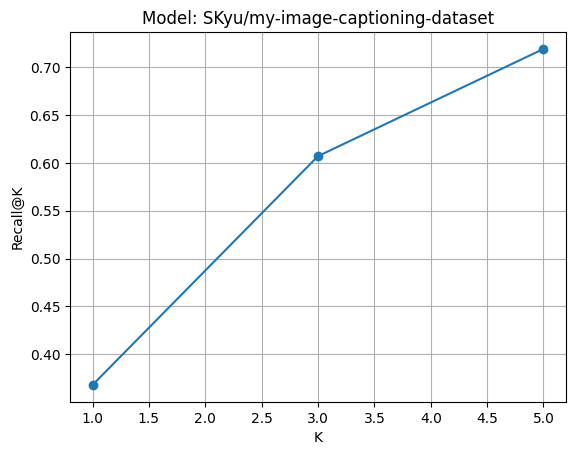


2. Evaluating Fine-Tuned Model:
----------------------------------------------------------------------
Processing Batch 1
Recall@1: 56.0000
Recall@3: 82.0000
Recall@5: 88.0000
Processing Batch 2
Recall@1: 61.0000
Recall@3: 87.0000
Recall@5: 91.0000
Processing Batch 3
Recall@1: 51.3333
Recall@3: 76.0000
Recall@5: 84.0000
Processing Batch 4
Recall@1: 56.0000
Recall@3: 79.5000
Recall@5: 86.5000
Processing Batch 5
Recall@1: 57.2000
Recall@3: 82.0000
Recall@5: 89.2000
Processing Batch 6
Recall@1: 59.0000
Recall@3: 83.6667
Recall@5: 90.0000
Processing Batch 7
Recall@1: 59.7143
Recall@3: 84.0000
Recall@5: 90.5714
Processing Batch 8
Recall@1: 58.2500
Recall@3: 84.0000
Recall@5: 91.0000
Processing Batch 9
Recall@1: 59.5556
Recall@3: 84.2222
Recall@5: 91.3333
Processing Batch 10
Recall@1: 60.4000
Recall@3: 85.0000
Recall@5: 91.8000
Processing Batch 11
Recall@1: 60.3636
Recall@3: 84.9091
Recall@5: 91.6364
Processing Batch 12
Recall@1: 60.5000
Recall@3: 84.1667
Recall@5: 91.0000
Processing Batch 

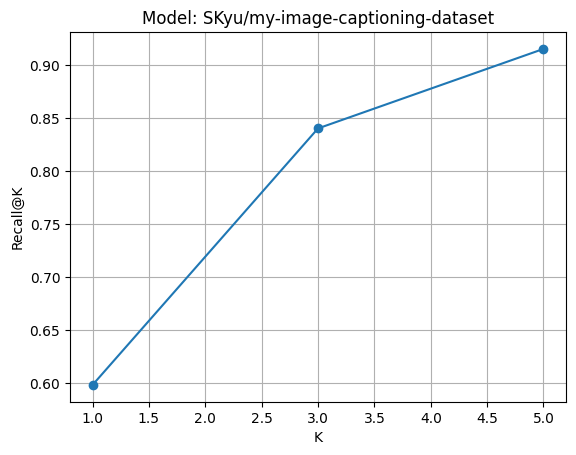


COMPARISON RESULTS
      Metric Baseline Model Fine-Tuned Model Improvement
Recall@1 (%)          36.80            59.80     +23.00%
Recall@3 (%)          60.70            84.00     +23.30%
Recall@5 (%)          71.90            91.50     +19.60%
   Test Loss         2.3638           1.3216     +1.0422


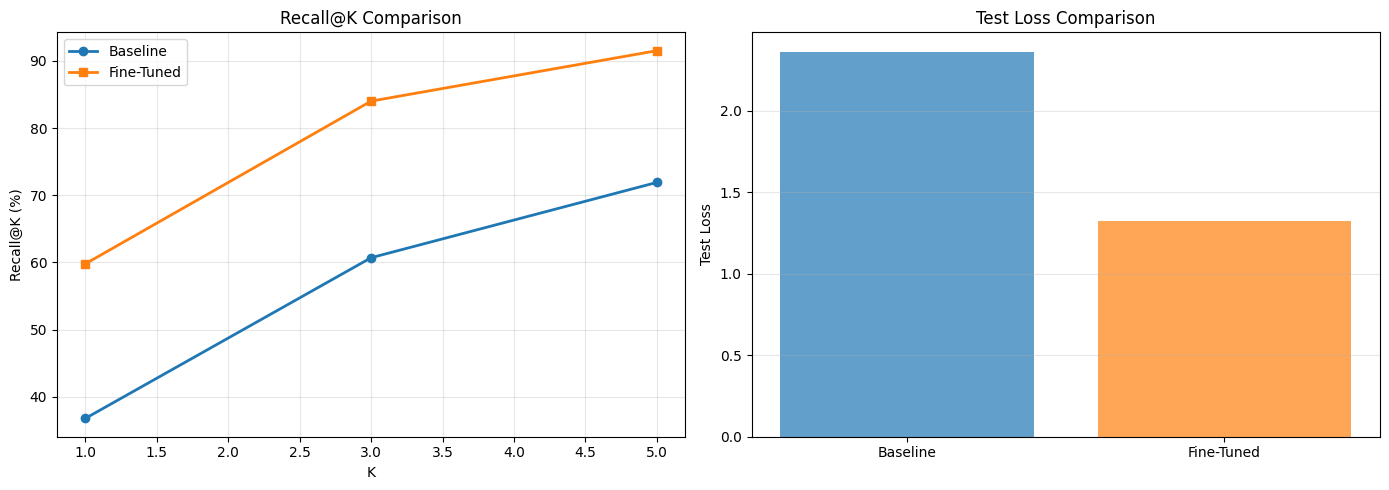


SUMMARY
Baseline Model - Recall@1: 36.80%, Test Loss: 2.3638
Fine-Tuned Model - Recall@1: 59.80%, Test Loss: 1.3216

Improvement in Recall@1: +23.00%
Reduction in Test Loss: +1.0422


In [4]:
import pandas as pd
import numpy as np

print("="*70)
print("MODEL COMPARISON: Baseline vs Fine-Tuned")
print("="*70)

# Evaluate baseline model
print("\n1. Evaluating Baseline Model (Pre-trained CLIP):")
print("-" * 70)
baseline_model = AutoModelForZeroShotImageClassification.from_pretrained("openai/clip-vit-base-patch32")
baseline_processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Temporarily swap models for baseline evaluation
original_model = model
original_processor = processor
model = baseline_model
processor = baseline_processor

baseline_recalls, baseline_test_loss = evaluateModel(
    "SKyu/my-image-captioning-dataset",
    "train",
    "image",
    "prompt",
    50,
    1000,
    compute_loss=True
)

# Restore fine-tuned model
model = original_model
processor = original_processor

print("\n2. Evaluating Fine-Tuned Model:")
print("-" * 70)
fine_tuned_recalls, fine_tuned_test_loss = evaluateModel(
    "SKyu/my-image-captioning-dataset",
    "train",
    "image",
    "prompt",
    50,
    1000,
    compute_loss=True
)

# Create comparison table
print("\n" + "="*70)
print("COMPARISON RESULTS")
print("="*70)

comparison_data = {
    'Metric': ['Recall@1 (%)', 'Recall@3 (%)', 'Recall@5 (%)', 'Test Loss'],
    'Baseline Model': [
        f"{baseline_recalls[0]*100:.2f}",
        f"{baseline_recalls[1]*100:.2f}",
        f"{baseline_recalls[2]*100:.2f}",
        f"{baseline_test_loss:.4f}"
    ],
    'Fine-Tuned Model': [
        f"{fine_tuned_recalls[0]*100:.2f}",
        f"{fine_tuned_recalls[1]*100:.2f}",
        f"{fine_tuned_recalls[2]*100:.2f}",
        f"{fine_tuned_test_loss:.4f}"
    ],
    'Improvement': [
        f"{(fine_tuned_recalls[0] - baseline_recalls[0])*100:+.2f}%",
        f"{(fine_tuned_recalls[1] - baseline_recalls[1])*100:+.2f}%",
        f"{(fine_tuned_recalls[2] - baseline_recalls[2])*100:+.2f}%",
        f"{(baseline_test_loss - fine_tuned_test_loss):+.4f}"
    ]
}

df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall comparison
Ks = [1, 3, 5]
axes[0].plot(Ks, [r*100 for r in baseline_recalls], marker='o', label='Baseline', linewidth=2)
axes[0].plot(Ks, [r*100 for r in fine_tuned_recalls], marker='s', label='Fine-Tuned', linewidth=2)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Recall@K (%)')
axes[0].set_title('Recall@K Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss comparison
axes[1].bar(['Baseline', 'Fine-Tuned'], [baseline_test_loss, fine_tuned_test_loss],
            color=['#1f77b4', '#ff7f0e'], alpha=0.7)
axes[1].set_ylabel('Test Loss')
axes[1].set_title('Test Loss Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Baseline Model - Recall@1: {baseline_recalls[0]*100:.2f}%, Test Loss: {baseline_test_loss:.4f}")
print(f"Fine-Tuned Model - Recall@1: {fine_tuned_recalls[0]*100:.2f}%, Test Loss: {fine_tuned_test_loss:.4f}")
print(f"\nImprovement in Recall@1: {(fine_tuned_recalls[0] - baseline_recalls[0])*100:+.2f}%")
print(f"Reduction in Test Loss: {(baseline_test_loss - fine_tuned_test_loss):+.4f}")
print("="*70)

Extracting baseline embeddings...
Extracting fine-tuned embeddings...
Creating t-SNE visualizations...


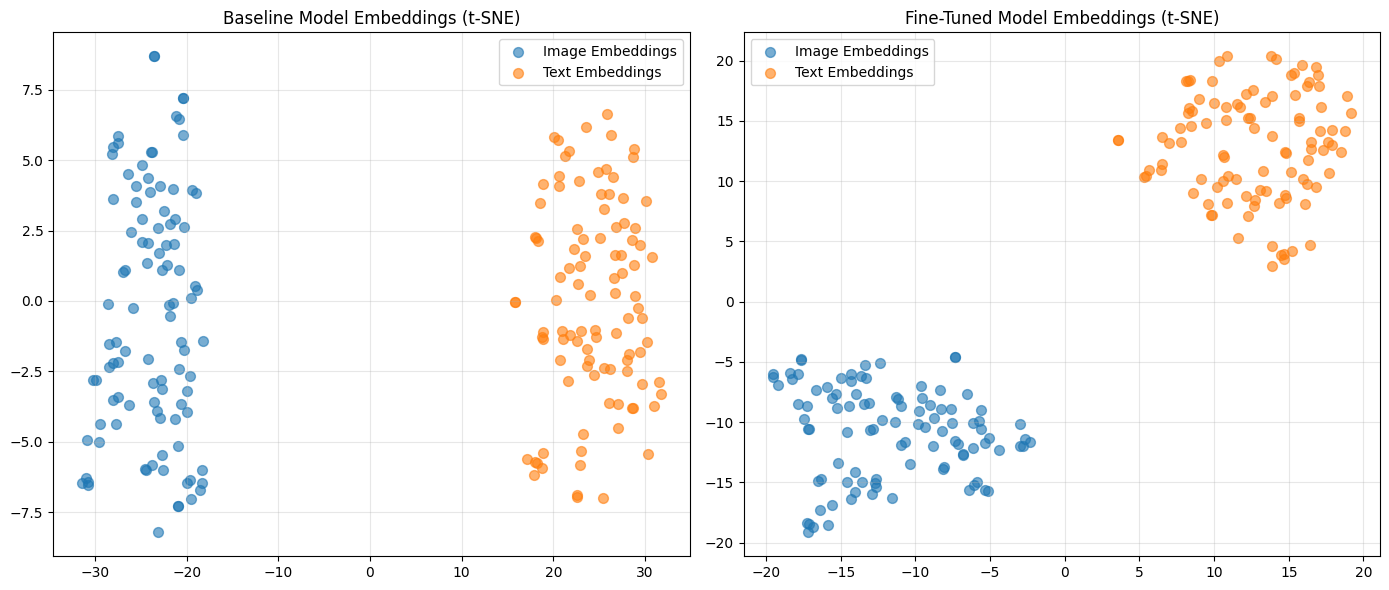


Embedding Alignment (Average Cosine Similarity):
Baseline: 0.2921
Fine-Tuned: 0.3302
Improvement: +0.0381


In [5]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np

# Extract embeddings for visualization
def extract_embeddings(model, processor, dataset, num_samples=100):
    model.eval()
    images = []
    texts = []
    image_embeddings = []
    text_embeddings = []

    sample_dataset = dataset.select(range(num_samples))

    with torch.no_grad():
        for item in sample_dataset:
            image = item["image"]
            text = item["prompt"]

            inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True)
            outputs = model(**inputs)

            # Get normalized embeddings
            image_emb = outputs.image_embeds / outputs.image_embeds.norm(dim=-1, keepdim=True)
            text_emb = outputs.text_embeds / outputs.text_embeds.norm(dim=-1, keepdim=True)

            image_embeddings.append(image_emb.squeeze().numpy())
            text_embeddings.append(text_emb.squeeze().numpy())

    return np.array(image_embeddings), np.array(text_embeddings)

# Get embeddings from baseline and fine-tuned models
print("Extracting baseline embeddings...")
baseline_model.eval()
baseline_img_emb, baseline_txt_emb = extract_embeddings(baseline_model, baseline_processor, test_dataset, 100)

print("Extracting fine-tuned embeddings...")
model.eval()
fine_tuned_img_emb, fine_tuned_txt_emb = extract_embeddings(model, processor, test_dataset, 100)

# Visualize with t-SNE
print("Creating t-SNE visualizations...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Baseline embeddings
baseline_combined = np.vstack([baseline_img_emb, baseline_txt_emb])
baseline_2d = tsne.fit_transform(baseline_combined)

# Fine-tuned embeddings
fine_tuned_combined = np.vstack([fine_tuned_img_emb, fine_tuned_txt_emb])
fine_tuned_2d = tsne.fit_transform(fine_tuned_combined)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(baseline_2d[:100, 0], baseline_2d[:100, 1], alpha=0.6, label='Image Embeddings', s=50)
axes[0].scatter(baseline_2d[100:, 0], baseline_2d[100:, 1], alpha=0.6, label='Text Embeddings', s=50)
axes[0].set_title('Baseline Model Embeddings (t-SNE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(fine_tuned_2d[:100, 0], fine_tuned_2d[:100, 1], alpha=0.6, label='Image Embeddings', s=50)
axes[1].scatter(fine_tuned_2d[100:, 0], fine_tuned_2d[100:, 1], alpha=0.6, label='Text Embeddings', s=50)
axes[1].set_title('Fine-Tuned Model Embeddings (t-SNE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate embedding alignment (cosine similarity)
def calculate_alignment(img_emb, txt_emb):
    similarities = []
    for i in range(len(img_emb)):
        sim = np.dot(img_emb[i], txt_emb[i]) / (np.linalg.norm(img_emb[i]) * np.linalg.norm(txt_emb[i]))
        similarities.append(sim)
    return np.mean(similarities)

baseline_alignment = calculate_alignment(baseline_img_emb, baseline_txt_emb)
fine_tuned_alignment = calculate_alignment(fine_tuned_img_emb, fine_tuned_txt_emb)

print(f"\nEmbedding Alignment (Average Cosine Similarity):")
print(f"Baseline: {baseline_alignment:.4f}")
print(f"Fine-Tuned: {fine_tuned_alignment:.4f}")
print(f"Improvement: {fine_tuned_alignment - baseline_alignment:+.4f}")